In [1]:
import pandas as pd
import numpy as np

rfm = pd.read_parquet("../data/processed/customer_rfm.parquet")
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Is_Churned
0,12346.0,145,12,77556.46,1
1,12347.0,2,5,3529.27,0
2,12348.0,68,4,1709.40,0
3,12349.0,227,3,2671.14,0
4,12350.0,129,1,334.40,1


In [2]:
# we cluster on R, F, M only — not Customer ID (an identifier) or Is_Churned (that's Phase 3's job)
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()
features.head()

,Recency,Frequency,Monetary
0,145,12,77556.46
1,2,5,3529.27
2,68,4,1709.40
3,227,3,2671.14
4,129,1,334.40


In [3]:
 # log1p = log(1 + x), which safely handles any zeros
features_log = np.log1p(features)
features_log.describe()

,Recency,Frequency,Monetary
count,4979.000000,4979.000000,4979.000000
mean,4.566365,1.453780,6.718034
std,1.338295,0.757402,1.352476
min,0.000000,0.693147,0.000000
25%,3.650574,0.693147,5.769523
50%,4.990433,1.386294,6.662609
75%,5.531409,1.945910,7.607389
max,6.326149,5.575949,12.997469


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)

# peek at the result
pd.DataFrame(features_scaled, columns=features.columns).describe()

,Recency,Frequency,Monetary
count,4.979000e+03,4.979000e+03,4.979000e+03
mean,1.598329e-16,-7.135396e-19,-2.283327e-17
std,1.000100e+00,1.000100e+00,1.000100e+00
min,-3.412419e+00,-1.004367e+00,-4.967709e+00
25%,-6.843654e-01,-1.004367e+00,-7.013846e-01
50%,3.169034e-01,-8.911007e-02,-4.098475e-02
75%,7.211723e-01,6.498268e-01,6.576410e-01
max,1.315077e+00,5.443061e+00,4.643383e+00


In [5]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

print(inertias)

[14937.0, 7343.00679669736, 5549.448581806706, 4304.37474902601, 3602.065579136727, 3179.541193768788, 2842.357431748463, 2602.3461836326474, 2381.800366495335, 2179.087242457951]


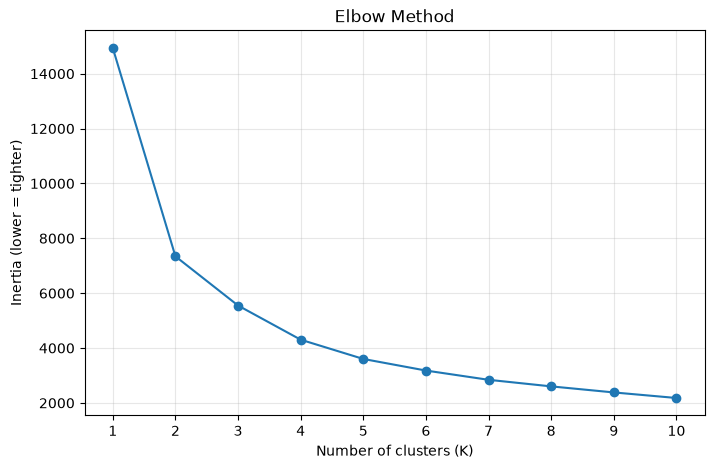

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (lower = tighter)')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    print(f"K={k}  silhouette score = {score:.3f}")

K=2  silhouette score = 0.456
K=3  silhouette score = 0.347


K=4  silhouette score = 0.372
K=5  silhouette score = 0.333


K=6  silhouette score = 0.318


In [8]:
best_k = 4   # change this if your scores clearly favor a different number

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(features_scaled)

In [9]:
# Cluster IDs are NOT stable — re-fitting K-Means (or changing the churn window)
# reshuffles them, so a hardcoded {0: 'Champions', ...} map silently mislabels
# everyone. Derive the names from each cluster's actual R/F/M profile instead.
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
profile['Customers'] = rfm.groupby('Cluster').size()
print(profile.round(1))

# Split the four centroids on recency and frequency; each quadrant is one segment.
recent   = profile['Recency']   < profile['Recency'].median()
frequent = profile['Frequency'] > profile['Frequency'].median()

segment_names = {}
for c in profile.index:
    if   recent[c]  and frequent[c]:  segment_names[c] = 'Champions'
    elif recent[c]:                   segment_names[c] = 'New Customers'
    elif frequent[c]:                 segment_names[c] = 'At-Risk'
    else:                             segment_names[c] = 'Hibernating'

print("\nMapping:", segment_names)
assert len(set(segment_names.values())) == 4, "clusters did not split into 4 distinct segments"

rfm['Segment'] = rfm['Cluster'].map(segment_names)
print(rfm['Segment'].value_counts())

         Recency  Frequency  Monetary  Customers
Cluster                                         
0           31.7       18.5   10735.4        778
1          275.2        1.3     325.6       2000
2           20.9        3.5    1070.4        708
3          180.1        4.6    1791.7       1493

Mapping: {0: 'Champions', 1: 'Hibernating', 2: 'New Customers', 3: 'At-Risk'}
Segment
Hibernating      2000
At-Risk          1493
Champions         778
New Customers     708
Name: count, dtype: int64


In [10]:
rfm.to_parquet("../data/processed/customer_segments.parquet", index=False)
print("Phase 2 complete. Segments saved.")

Phase 2 complete. Segments saved.


In [11]:
import joblib, json

joblib.dump(scaler, "../models/rfm_scaler.pkl")
joblib.dump(kmeans, "../models/kmeans.pkl")

# the app must use the same mapping this run produced, not a stale hardcoded one
with open("../models/segment_names.json", "w") as fh:
    json.dump({str(k): v for k, v in segment_names.items()}, fh, indent=2)

print("Scaler, K-Means and segment mapping saved.")

Scaler, K-Means and segment mapping saved.
